## Batch Gradient Descent for Linear Regression

This notebook delves into the core mechanics of **Batch Gradient Descent**, a fundamental optimization algorithm used to train machine learning models, specifically in the context of **Linear Regression**.

Linear regression aims to model the relationship between a dependent variable and one or more independent variables by fitting a linear equation to observed data. Gradient Descent is the engine that drives this fitting process by iteratively adjusting the model's parameters (weights or coefficients) to minimize a predefined cost function.

In this implementation, we will:
- Define the necessary functions for linear regression and gradient descent from scratch.
- Apply the algorithm to a dataset.
- Visualize the cost function's convergence.
- Demonstrate the critical impact of **feature scaling** on the performance and convergence speed of gradient descent by comparing the optimization paths on both unscaled and standardized features.

# Batch gradient descent

In [21]:
import numpy as np
import matplotlib.pyplot as plt


### Gradient Descent Function

This section defines the `gradient_descent` function, which is the core optimization algorithm used in linear regression. This function iteratively updates the model's parameters (theta) to minimize the cost function, guiding the model towards the best-fit line. Each iteration involves calculating the hypothesis, determining the error, computing the gradient, and then adjusting theta based on the learning rate (`alpha`). The historical cost `J` is also tracked to monitor convergence.

In [37]:
def gradient_descent(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = np.zeros((num_iters, 1))

    for i in range(num_iters):
        # Calculate the hypothesis
        h = X @ theta

        # Calculate the error
        error = h - y

        # Calculate the gradient
        gradient = (X.T @ error) / m

        # Update theta
        theta = theta - alpha * gradient

        # Calculate and store the cost function J
        # The cost function for linear regression is J(theta) = 1/(2*m) * sum((h(x) - y)^2)
        # Which can be vectorized as J(theta) = 1/(2*m) * (error.T @ error)
        cost = (1/(2*m)) * (error.T @ error).item()
        J_history[i, 0] = cost

    return theta, J_history

### Plotting Cost Function History

Let's visualize the cost function $J(\theta)$ over the iterations of gradient descent. This plot helps us understand if the algorithm is converging, and if so, how quickly. A decreasing cost function indicates that our model's parameters are being adjusted in a way that reduces the error on the training data.

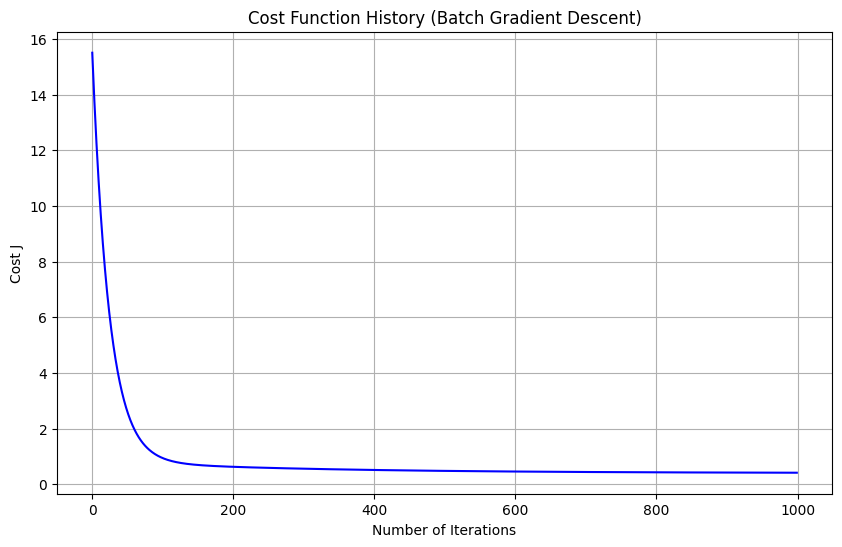

In [23]:
import matplotlib.pyplot as plt

# Convert J_history (list of arrays) to a single NumPy array
# and flatten it to handle (1,1) dimensions if present.
costs = np.array(J_history).flatten()

# Plot the cost function history
plt.figure(figsize=(10, 6))
plt.plot(range(len(costs)), costs, color='blue')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost J')
plt.title('Cost Function History (Batch Gradient Descent)')
plt.grid(True)
plt.show()

### Prediction Function

This `predict` function takes the feature matrix `X` and the learned parameters `theta` to generate predictions for the target variable. It's a simple matrix multiplication, representing the linear equation $h(X) = X \cdot \theta$.

In [38]:
def predict(X, theta):
    return X @ theta

### Linear Regression Wrapper Function

The `linear_regression` function orchestrates the entire training and prediction process. It initializes the model parameters, calls the `gradient_descent` function to optimize them, and then uses the optimized parameters to make predictions. This function provides a convenient interface to run our custom linear regression model.

In [39]:
def linear_regression(X, y, alpha, num_iters):
    # Initialize theta (parameters) with zeros. Add an extra dimension for the intercept.
    # The shape of theta should be (number_of_features + 1, 1) for X_b, or (number_of_features, 1) for X.
    # Assuming X already includes the bias term (X_b) if an intercept is needed, or the user will handle it.
    # Here, we'll initialize based on the number of columns in X.
    theta_init = np.zeros((X.shape[1], 1))

    # Run gradient descent
    theta_final, J_history = gradient_descent(X, y, theta_init, alpha, num_iters)

    # Make predictions
    y_pred = predict(X, theta_final)

    return theta_final, J_history, y_pred

### Evaluating Model Performance

After training the model, it's crucial to evaluate its performance using appropriate metrics. We'll calculate:

*   **R-squared (Coefficient of Determination):** A measure of how well the predictions approximate the real data points. An R-squared of 1 indicates that the model perfectly predicts the target variable.
*   **Mean Squared Error (MSE):** The average of the squared differences between the predicted and actual values. It's a measure of the average magnitude of the errors. Lower MSE indicates better fit.

In [25]:
# Calculate R-squared
y_mean = np.mean(y)
sst = np.sum((y - y_mean)**2)
residuals = y - y_pred
ssr = np.sum(residuals**2)
r_squared = 1 - (ssr / sst)
print(f"R-squared: {r_squared:.4f}")

# Calculate Mean Squared Error (MSE)
mse = np.mean((y - y_pred)**2)
print(f"Mean Squared Error (MSE): {mse:.4f}")

R-squared: 0.7693
Mean Squared Error (MSE): 0.8066


### Visualizing Actual vs. Predicted Values

This plot compares the actual target values (`y`) against the values predicted by our linear regression model (`y_pred`). A good model will have data points clustering closely around the red dashed line, which represents perfect prediction (where actual equals predicted).

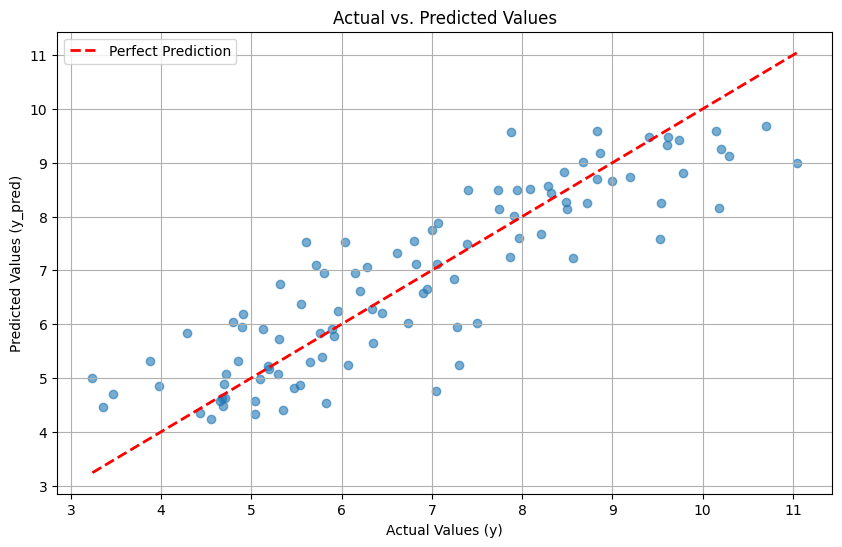

In [26]:
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction') # Add a line for perfect prediction
plt.xlabel('Actual Values (y)')
plt.ylabel('Predicted Values (y_pred)')
plt.title('Actual vs. Predicted Values')
plt.grid(True)
plt.legend()
plt.show()

### Feature Scaling (Standardization)

Feature scaling, specifically standardization, can help gradient descent converge faster and more reliably. It transforms the features to have a mean of 0 and a standard deviation of 1.

In [44]:
# Calculate mean and standard deviation of the feature X
mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

# Standardize X
X_scaled = (X - mu) / sigma

# Add the bias (intercept) term to the scaled X
X_scaled_b = np.c_[np.ones((len(X_scaled), 1)), X_scaled]

print("Original X shape:", X.shape)
print("Scaled X_b shape (with intercept):", X_scaled_b.shape)

Original X shape: (100, 1)
Scaled X_b shape (with intercept): (100, 2)


### Re-running Linear Regression with Scaled Features

Now, let's run the `linear_regression` function again using the standardized features (`X_scaled_b`).

In [40]:
# Run linear regression with scaled features
theta_final_scaled, J_history_scaled, y_pred_scaled = linear_regression(X_scaled_b, y, alpha, num_iters)

print("Theta after training with scaled features:", theta_final_scaled)

Theta after training with scaled features: [[6.81970967]
 [1.6398265 ]]


/tmp/ipykernel_23331/1853801505.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  J_history[i, 0] = cost


### Plotting Cost Function History (Scaled Features)

Let's visualize the cost function history for the gradient descent run with scaled features. We should observe a smoother and potentially faster convergence.

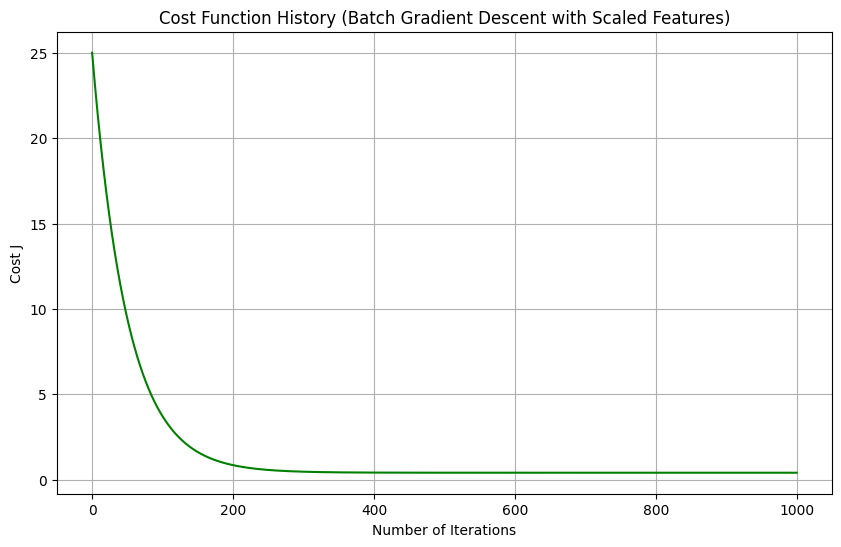

In [41]:
# Convert J_history_scaled (list of arrays) to a single NumPy array and flatten it.
costs_scaled = np.array(J_history_scaled).flatten()

# Plot the cost function history for scaled features
plt.figure(figsize=(10, 6))
plt.plot(range(len(costs_scaled)), costs_scaled, color='green')
plt.xlabel('Number of Iterations')
plt.ylabel('Cost J')
plt.title('Cost Function History (Batch Gradient Descent with Scaled Features)')
plt.grid(True)
plt.show()

### Evaluating Model Performance (Scaled Features)

Finally, let's re-evaluate the R-squared and MSE for the model trained with scaled features.

In [42]:
# Calculate R-squared for scaled features
y_mean_scaled = np.mean(y)
sst_scaled = np.sum((y - y_mean_scaled)**2)
residuals_scaled = y - y_pred_scaled
ssr_scaled = np.sum(residuals_scaled**2)
r_squared_scaled = 1 - (ssr_scaled / sst_scaled)
print(f"R-squared (Scaled Features): {r_squared_scaled:.4f}")

# Calculate Mean Squared Error (MSE) for scaled features
mse_scaled = np.mean((y - y_pred_scaled)**2)
print(f"Mean Squared Error (MSE) (Scaled Features): {mse_scaled:.4f}")

R-squared (Scaled Features): 0.7693
Mean Squared Error (MSE) (Scaled Features): 0.8066


In [45]:
# Calculate Mean Absolute Error (MAE) for scaled features
mae_scaled = np.mean(np.abs(y - y_pred_scaled))
print(f"Mean Absolute Error (MAE) (Scaled Features): {mae_scaled:.4f}")

Mean Absolute Error (MAE) (Scaled Features): 0.7010


### Gradient Descent with History Tracking

To visualize the optimization path, we'll need a modified version of our `gradient_descent` function that also tracks the `theta` values at each iteration. This will allow us to plot the trajectory of the parameters across the loss landscape.

### Visualizing Actual vs. Predicted Values (Scaled Features)

Let's also plot the actual vs. predicted values for the model trained with scaled features.

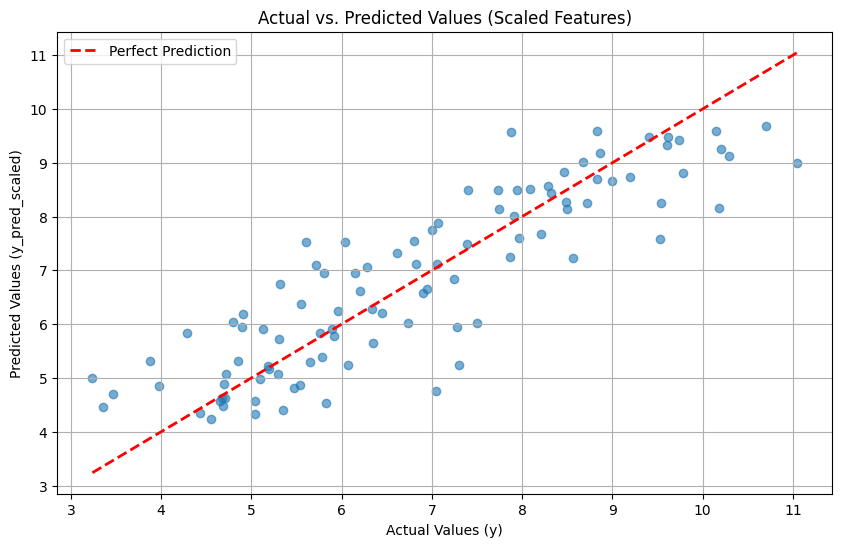

In [43]:
plt.figure(figsize=(10, 6))
plt.scatter(y, y_pred_scaled, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction') # Add a line for perfect prediction
plt.xlabel('Actual Values (y)')
plt.ylabel('Predicted Values (y_pred_scaled)')
plt.title('Actual vs. Predicted Values (Scaled Features)')
plt.grid(True)
plt.legend()
plt.show()

In [46]:
def gradient_descent_with_history(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = np.zeros(num_iters)
    # Create an array to store the theta values at each step
    theta_history = np.zeros((num_iters, len(theta)))

    # Ensure theta is float to avoid dtype issues during updates
    theta = theta.astype(float)

    for i in range(num_iters):
        # Calculate hypothesis, error, and gradient (Vectorized)
        h = X @ theta
        error = h - y
        gradient = (X.T @ error) / m

        # Update theta
        theta = theta - alpha * gradient

        # Calculate cost and extract scalar using .item()
        cost = (1/(2*m)) * (error.T @ error).item()

        # Store history
        J_history[i] = cost
        theta_history[i, :] = theta.flatten()

    return theta, J_history, theta_history

### Visualizing the Loss Landscape and Gradient Descent Path

Now, let's create a function to plot the 2D loss landscape for a simple linear regression problem (with two parameters: intercept $\theta_0$ and slope $\theta_1$). This function will also overlay the path taken by the gradient descent algorithm.

In [47]:
def plot_loss_landscape(X, y, theta_history, title):
    # 1. Determine the grid boundaries based on the trajectory
    t0_min, t0_max = min(theta_history[:, 0]), max(theta_history[:, 0])
    t1_min, t1_max = min(theta_history[:, 1]), max(theta_history[:, 1])

    # Add a margin to the grid so the trajectory isn't right on the edge
    margin_0 = abs(t0_max - t0_min) * 0.5 + 0.5
    margin_1 = abs(t1_max - t1_min) * 0.5 + 0.5

    t0_range = np.linspace(t0_min - margin_0, t0_max + margin_0, 100)
    t1_range = np.linspace(t1_min - margin_1, t1_max + margin_1, 100)

    T0, T1 = np.meshgrid(t0_range, t1_range)
    J_grid = np.zeros_like(T0)

    # 2. Calculate the cost for every point on the grid
    m = len(y)
    for i in range(T0.shape[0]):
        for j in range(T0.shape[1]):
            theta_temp = np.array([[T0[i, j]], [T1[i, j]]])
            error = (X @ theta_temp) - y
            J_grid[i, j] = (1/(2*m)) * (error.T @ error).item()

    # 3. Plotting
    plt.figure(figsize=(10, 8))

    # We use a logarithmic scale for contour levels to see the "bowl" shape clearly
    levels = np.logspace(np.log10(J_grid.min()), np.log10(J_grid.max()), 20)
    contours = plt.contour(T0, T1, J_grid, levels=levels, cmap='viridis', alpha=0.8)

    # Plot the gradient descent trajectory
    plt.plot(theta_history[:, 0], theta_history[:, 1], 'r-o', markersize=4,
             linewidth=1.5, label='Gradient Descent Path')

    # Mark the final point (Global Minimum)
    plt.plot(theta_history[-1, 0], theta_history[-1, 1], 'r*', markersize=12, label='Final Theta')

    plt.xlabel('Theta 0 (Intercept)')
    plt.ylabel('Theta 1 (Slope)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

### Comparing Loss Landscapes: Unscaled vs. Standardized Features

Let's apply our new `gradient_descent_with_history` and `plot_loss_landscape` functions to both the original (unscaled) features and the standardized features. We'll use different learning rates (`alpha`) to highlight the benefits of feature scaling.

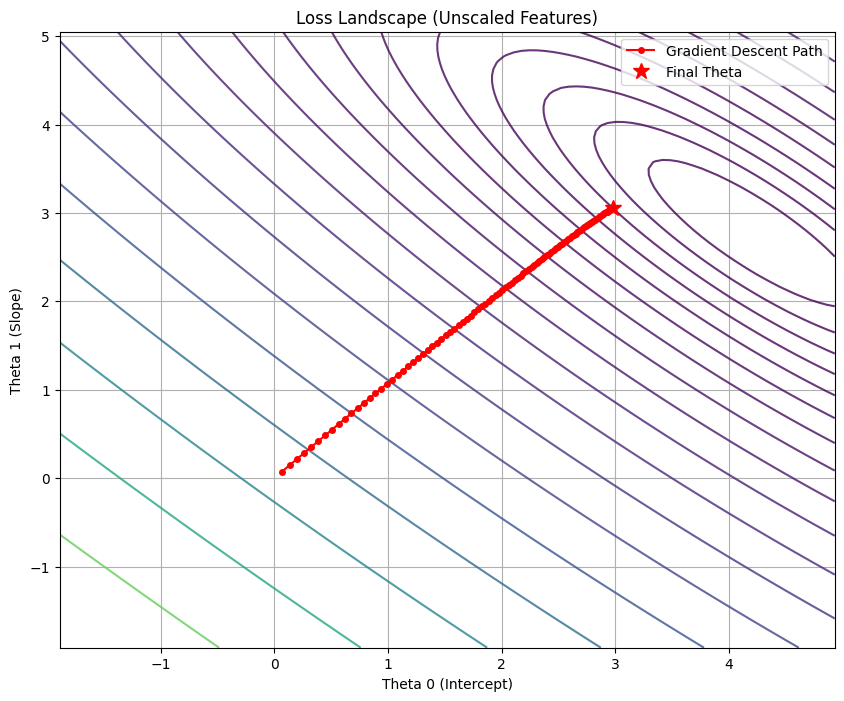

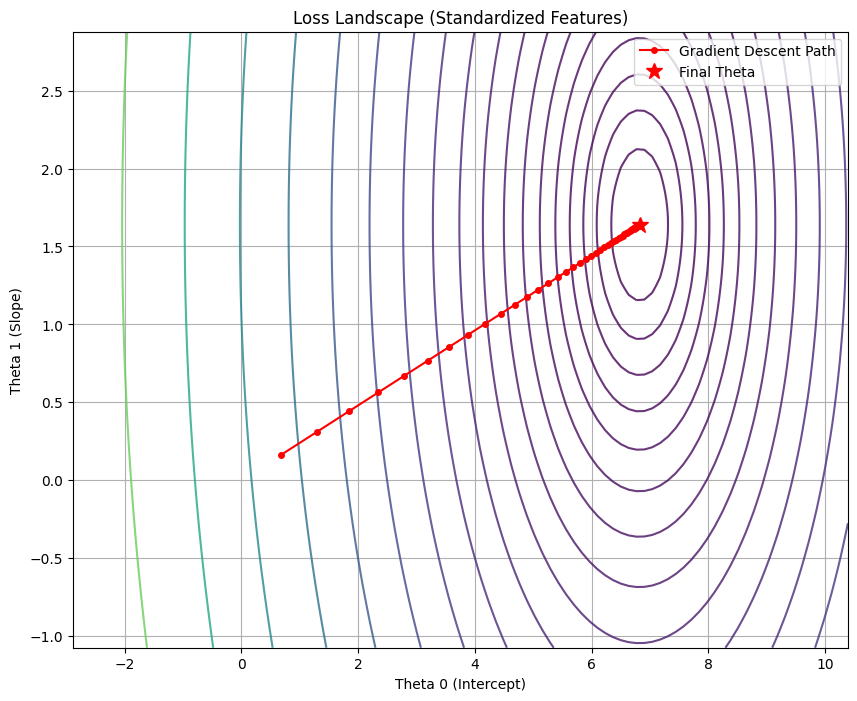

In [48]:
# Assuming X_b is your original X with the intercept column added
# and X_scaled_b is your scaled X with the intercept column added
alpha = 0.01  # You may need to adjust this depending on your data
num_iters = 100

# --- 1. Run for UNSCALED Features ---
theta_init = np.zeros((2, 1))
_, _, theta_hist_unscaled = gradient_descent_with_history(X_b, y, theta_init, alpha, num_iters)

# --- 2. Run for SCALED Features ---
theta_init_scaled = np.zeros((2, 1))
# We use a larger alpha for scaled features because it converges more stably
alpha_scaled = 0.1
_, _, theta_hist_scaled = gradient_descent_with_history(X_scaled_b, y, theta_init_scaled, alpha_scaled, num_iters)

# --- 3. Plot Both ---
plot_loss_landscape(X_b, y, theta_hist_unscaled, 'Loss Landscape (Unscaled Features)')
plot_loss_landscape(X_scaled_b, y, theta_hist_scaled, 'Loss Landscape (Standardized Features)')

### Conclusion: The Impact of Feature Scaling on Gradient Descent

This notebook demonstrates a ground-up implementation of linear regression and highlights exactly why feature scaling (standardization) is a critical step in machine learning optimization.

By tracking the trajectory of the parameters ($\theta$) and plotting the $J(\theta)$ cost function, we can visually prove how scaling affects the algorithm:

* **The "Narrow Valley" (Unscaled Features):** When features are on vastly different scales, the loss landscape becomes highly elliptical and skewed. Gradient descent struggles here, often "zigzagging" back and forth across the steep walls of the valley, requiring a smaller learning rate and more iterations to slowly find the bottom.
* **The "Symmetrical Bowl" (Standardized Features):** By transforming the features to have a mean of 0 and a standard deviation of 1, the loss landscape becomes beautifully circular. The negative gradient now points almost perfectly toward the global minimum, allowing the algorithm to take a direct, stable, and much faster path to convergence using a larger learning rate.
* **Identical Final Performance:** Feature scaling does not alter the theoretical global minimum of the dataset. Despite the difference in training speed and efficiency, both the unscaled and scaled models ultimately converge to the exact same predictive accuracy ($R^2 \approx 0.7693$, $MSE \approx 0.8066$).

**Technical Note on NumPy Deprecation:** During the initial unscaled run, a `DeprecationWarning` may appear when storing the cost history. This happens in newer NumPy versions when assigning a 2D array of shape `(1, 1)` (the result of `error.T @ error`) to a strictly 1D scalar array index. Extracting the scalar value using `.item()` resolves this.